# Describing a pull of OBIS records — Atlantic cod

[OBISClient.jl](https://github.com/dantebertuzzi/OBISClient.jl) is a Julia client for
[OBIS](https://obis.org), the Ocean Biodiversity Information System, a programme of the
Intergovernmental Oceanographic Commission of UNESCO.

> **Not an official OBIS product.** This is an independent, community-maintained client, not
> affiliated with or endorsed by OBIS, the IOC, or UNESCO. The data, the API and the quality
> control behind them are the work of OBIS and its nodes.

Descriptive statistics is what happens before any model: centre, spread, shape, and the
categories. On occurrence records it is also where the data tells you what it is. Every
distribution below has two readings — one about cod, one about the people who went looking
for cod — and most of the time the second is the louder of the two.

The figures are CairoMakie, on the palette the package's own figures use. Plotting is not
part of OBISClient.jl: the client hands over a Tables.jl table and stops there.

Everything runs live against the API, so the numbers here will not match the ones committed
with this notebook.

In [ ]:
using Pkg
Pkg.add(["OBISClient", "DataFrames", "CairoMakie"])

In [2]:
using OBISClient, DataFrames, CairoMakie, Statistics

## The figure theme

The palette comes from [`examples/theme.jl`](https://github.com/dantebertuzzi/OBISClient.jl/blob/main/examples/theme.jl),
which is where the maps in the repository get theirs, and which also carries the dark
variant. Two categorical hues, far enough apart to survive colour-vision deficiency; a
sequential ramp for magnitude; a diverging ramp around a neutral grey for anything that has
a sign, so that "no departure" reads as nothing rather than as a colour.

In [3]:
# The light half of examples/theme.jl. `seq` is the sequential ramp, `div` the diverging one.
const P = (
    surface = "#fcfcfb", ink     = "#0b0b0b", ink2 = "#52514e", muted = "#898781",
    grid    = "#e1e0d9", axis    = "#c3c2b7",
    series1 = "#2a78d6", series2 = "#eb6834",
    seq = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
    div = ["#752322", "#d2383a", "#f9aaa3", "#f0efec", "#9ec5f4", "#2a78d6", "#104281"],
)

set_theme!(Theme(
    backgroundcolor = P.surface, textcolor = P.ink, fontsize = 13, figure_padding = 18,
    Axis = (
        backgroundcolor = P.surface,
        xgridcolor = P.grid, ygridcolor = P.grid,
        leftspinevisible = false, rightspinevisible = false, topspinevisible = false,
        bottomspinecolor = P.axis, xtickcolor = P.muted, ytickcolor = P.muted,
        xticklabelcolor = P.ink2, yticklabelcolor = P.ink2,
        xlabelcolor = P.ink2, ylabelcolor = P.ink2,
        titlecolor = P.ink, titlealign = :left, titlesize = 15,
        subtitlecolor = P.ink2, subtitlesize = 12, subtitlegap = 6,
    ),
    Legend = (framevisible = false, labelcolor = P.ink2, labelsize = 11, patchsize = (12, 12)),
))

CairoMakie.activate!(type = "png", px_per_unit = 2)

## The pull

Atlantic cod, *Gadus morhua* — among the most heavily recorded species in OBIS. Three
million records is exactly what makes it a good subject: at that volume, what a five
thousand record pull looks like is decided by which programmes published, not by the fish.

Records arrive ordered by record UUID. A UUID is random, so the order is unrelated to date,
place or dataset, and the first five thousand behave like a random sample **of the query** —
a claim the last section of this notebook actually tests rather than assumes.

In [4]:
const SPECIES = "Gadus morhua"

st   = OBISClient.statistics(SPECIES)
recs = OBISClient.occurrence(SPECIES; limit = 5_000)
df   = DataFrame(recs)

(matched   = st["records"],
 datasets  = st["datasets"],
 years     = (st["yearrange"][1], st["yearrange"][2]),
 retrieved = nrow(df),
 accessed  = OBISClient.metadata(recs).accessed)

(matched = 3116283, datasets = 244, years = (1753, 2026), retrieved = 5000, accessed = Dates.Date("2026-09-12"))

## What is in the columns

The core schema is the same for every query, which means most of these columns exist here
whether or not this particular pull has values for them. Two groups are worth separating
before computing anything:

- `depth`, `individualCount`, `lifeStage`, `sex` and the rest of the observation detail come
  from the provider. They are present when somebody recorded them, which is often not.
- `sst`, `sss`, `bathymetry` and `shoredistance` do not. OBIS's quality pipeline looks them
  up from gridded data at the record's coordinates
  ([xylookup](https://github.com/iobis/xylookup)), so they are present on almost every
  record that has a position at all — and they describe the grid cell, not the moment the
  animal was seen.

That difference runs through everything below: the fields with near-complete coverage are
the derived ones.

In [5]:
values_of(col) = collect(skipmissing(df[!, col]))

coverage = DataFrame(
    field   = [:depth, :individualCount, :lifeStage, :sex, :sst, :sss, :bathymetry, :shoredistance],
    source  = ["provider", "provider", "provider", "provider", "OBIS lookup", "OBIS lookup",
               "OBIS lookup", "OBIS lookup"],
)
coverage.present_pct = [round(100 * count(!ismissing, df[!, f]) / nrow(df); digits = 1)
                        for f in coverage.field]
coverage

Row,field,source,present_pct
,Symbol,String,Float64
1,depth,provider,33.4
2,individualCount,provider,74.3
3,lifeStage,provider,9.4
4,sex,provider,13.1
5,sst,OBIS lookup,99.2
6,sss,OBIS lookup,99.2
7,bathymetry,OBIS lookup,100.0
8,shoredistance,OBIS lookup,100.0


## Centre, spread, shape

One table, computed by hand rather than by `describe`, because the two columns worth having
are the ones `describe` does not print: how much of the field is actually there, and how
far from symmetric it is.

In [6]:
"Skewness: the third standardized moment, zero for a symmetric sample."
function skewness(x)
    m, s = mean(x), std(x)
    return s == 0 ? NaN : mean(((x .- m) ./ s) .^ 3)
end

function describe_numeric(df, cols)
    return DataFrame(map(cols) do col
        x = Float64.(collect(skipmissing(df[!, col])))
        r(v) = round(v; digits = 2)
        (field       = col,
         present_pct = round(100 * length(x) / nrow(df); digits = 1),
         min         = r(minimum(x)),
         q25         = r(quantile(x, 0.25)),
         median      = r(median(x)),
         mean        = r(mean(x)),
         q75         = r(quantile(x, 0.75)),
         max         = r(maximum(x)),
         sd          = r(std(x)),
         skew        = r(skewness(x)))
    end)
end

describe_numeric(df, [:sst, :sss, :depth, :bathymetry, :shoredistance,
                      :individualCount, :date_year, :decimalLatitude])

Row,field,present_pct,min,q25,median,mean,q75,max,sd,skew
,Symbol,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,sst,99.2,-1.09,3.03,5.98,6.51,9.88,15.52,3.19,0.26
2,sss,99.2,6.48,31.16,31.25,28.82,31.66,35.54,7.83,-2.25
3,depth,33.4,-9.0,25.0,45.0,90.2,110.0,991.0,104.56,2.14
4,bathymetry,100.0,-410.0,-2.0,38.8,60.18,85.0,3086.0,103.35,7.01
5,shoredistance,100.0,-73321.0,220.0,1321.5,34345.1,36906.2,594237.0,63494.8,2.73
6,individualCount,74.3,0.38,1.0,1.0,26.54,1.0,36201.0,603.58,58.07
7,date_year,99.5,1894.0,1994.0,2009.0,2002.61,2012.0,2025.0,15.08,-1.4
8,decimalLatitude,100.0,-42.6,48.18,52.58,51.46,52.61,81.27,4.99,-0.35


Read the gap between `mean` and `median` first. Where the two are close the distribution is
roughly symmetric and the mean is a summary; where the mean sits far above the median, as it
does for `shoredistance` and `individualCount`, the mean is being dragged by a tail and is
not a typical value of anything.

`skew` puts a number on that — zero for symmetric, positive for a right tail. A skew above 2
means reporting the mean alone would misdescribe the sample badly enough to matter.

`present_pct` is the other column to read early. A statistic computed on a field that is
present in a third of the records is a statistic about that third, and nothing guarantees
the third is like the rest.

## Four fields, four shapes

Four distributions, four different reasons to be careful with them.

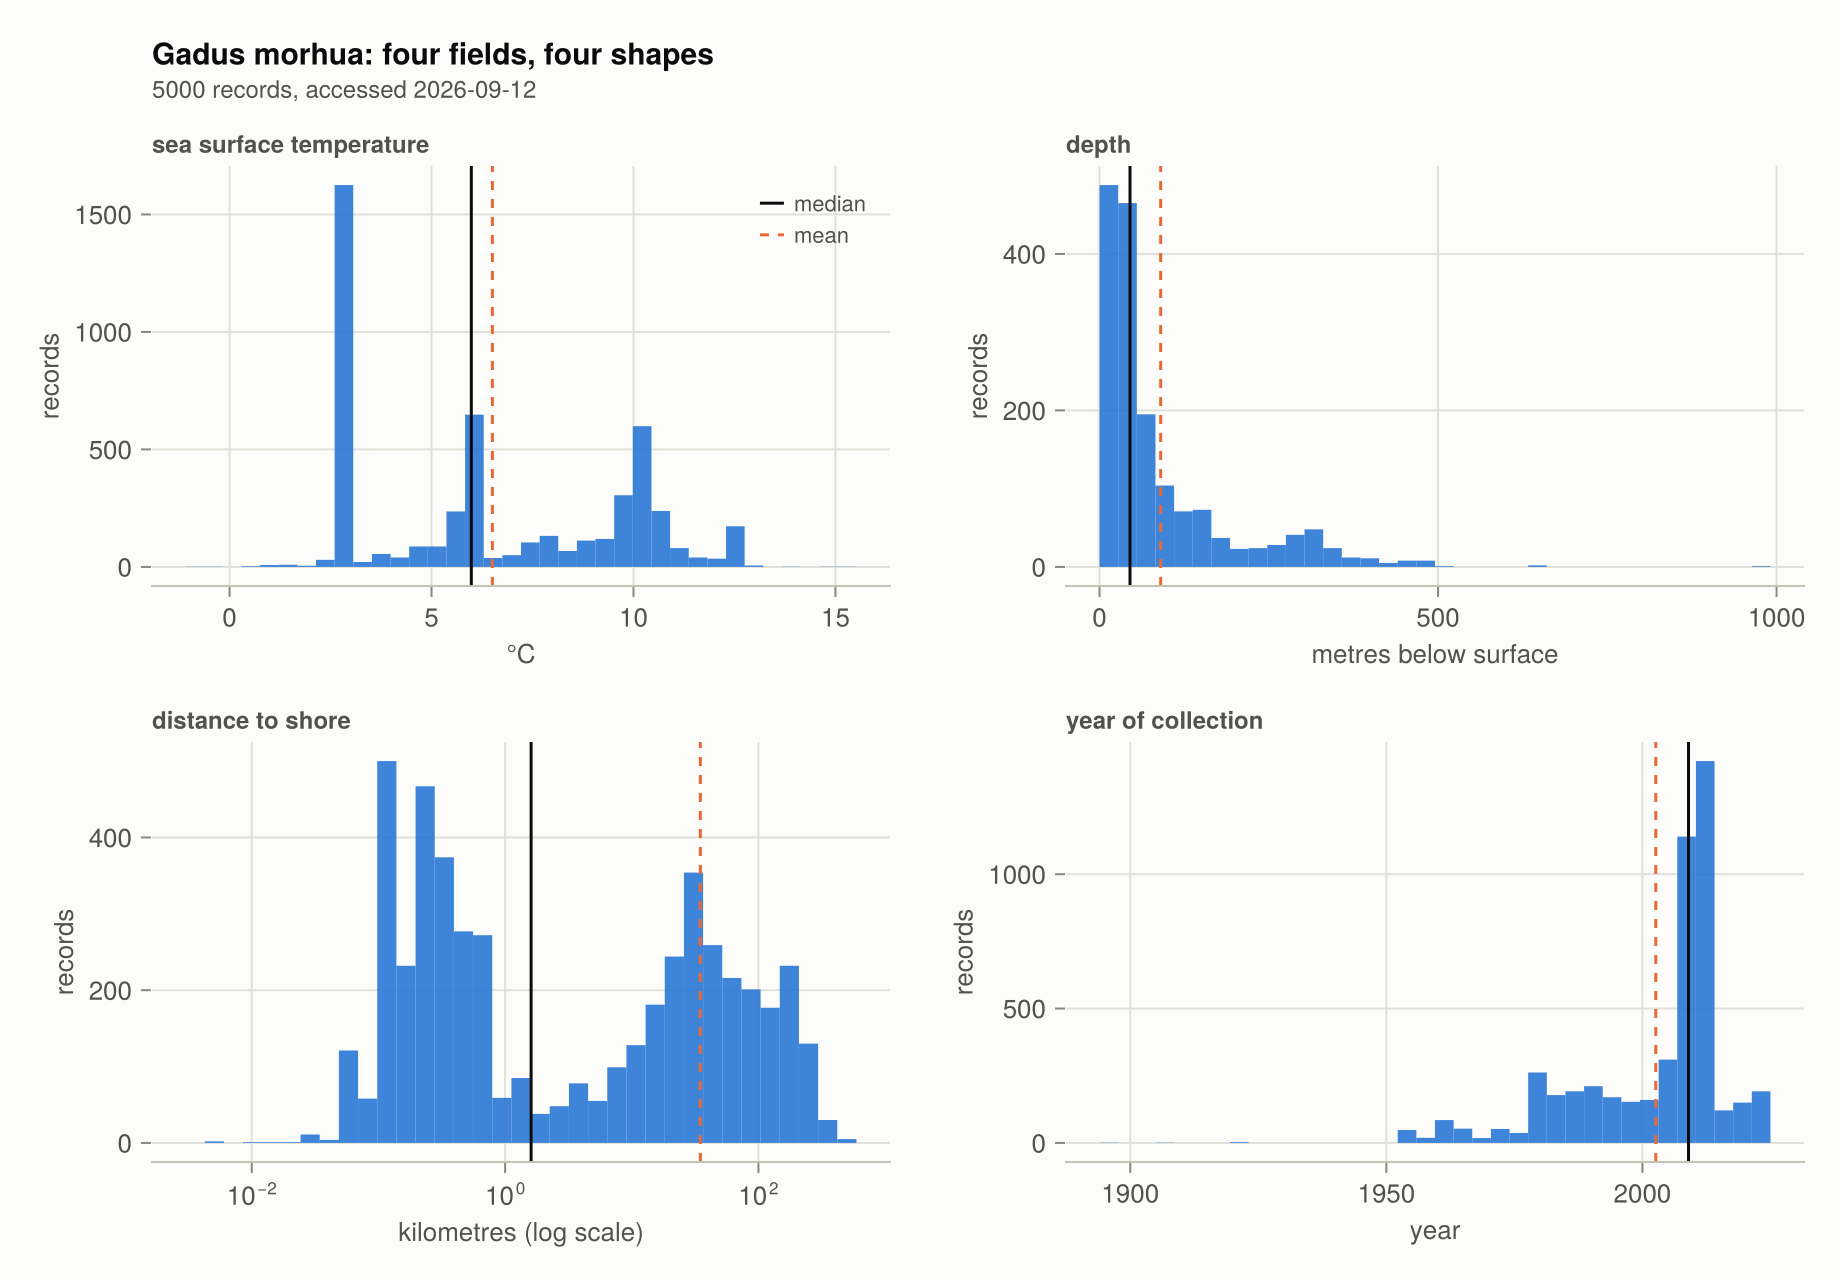

In [7]:
"A histogram with the median solid and the mean dashed: the gap between them is the point."
function shape_panel!(ax, x; bins = 36, legend = false)
    hist!(ax, x; bins = bins, color = (P.series1, 0.9), strokewidth = 0)
    vlines!(ax, [median(x)]; color = P.ink, linewidth = 1.5, label = "median")
    vlines!(ax, [mean(x)]; color = P.series2, linewidth = 1.5, linestyle = :dash, label = "mean")
    legend && axislegend(ax; position = :rt)
    return ax
end

fig = Figure(size = (920, 640))
Label(fig[1, 1:2], "$(SPECIES): four fields, four shapes";
      color = P.ink, fontsize = 15, font = :bold, halign = :left, tellwidth = false)
Label(fig[2, 1:2], "$(nrow(df)) records, accessed $(OBISClient.metadata(recs).accessed)";
      color = P.ink2, fontsize = 12, halign = :left, tellwidth = false)

ax1 = Axis(fig[3, 1]; title = "sea surface temperature", titlesize = 12, titlecolor = P.ink2,
           xlabel = "°C", ylabel = "records")
shape_panel!(ax1, values_of(:sst); legend = true)

ax2 = Axis(fig[3, 2]; title = "depth", titlesize = 12, titlecolor = P.ink2,
           xlabel = "metres below surface", ylabel = "records")
shape_panel!(ax2, filter(>=(0), values_of(:depth)))

km = filter(>(0), values_of(:shoredistance)) ./ 1000
ax3 = Axis(fig[4, 1]; title = "distance to shore", titlesize = 12, titlecolor = P.ink2,
           xlabel = "kilometres (log scale)", ylabel = "records", xscale = log10)
shape_panel!(ax3, km; bins = 10 .^ range(log10(minimum(km)), log10(maximum(km)); length = 36))

ax4 = Axis(fig[4, 2]; title = "year of collection", titlesize = 12, titlecolor = P.ink2,
           xlabel = "year", ylabel = "records")
shape_panel!(ax4, Float64.(values_of(:date_year)))

rowgap!(fig.layout, 1, 2); rowgap!(fig.layout, 2, 14); rowgap!(fig.layout, 3, 20)
colgap!(fig.layout, 1, 30)
fig

**Sea surface temperature** is multimodal — two or three peaks with gaps between them. No
thermal preference produces a gap; the next section shows what does.

**Depth** is the ordinary right-skewed shape of a variable censored at zero, with a spike in
the shallowest bin. Part of that spike is real, since cod are shelf fish, and part of it is
recording convention: a surface tow and an unrecorded depth can both arrive as a zero.

**Distance to shore** needs a log axis to be legible at all, which is itself the diagnostic.
The two humps are two kinds of programme — inshore arrays whose records sit a few hundred
metres from the coast, and offshore survey hauls tens to hundreds of kilometres out. One
column, two populations, and a median that falls in the valley between them where
comparatively few records are.

**Year of collection** is not biology in any part. Three quarters of the pull is 1994 or
later, and the shape is digitization projects, survey funding and the lag between a survey
and its publication to OBIS. Read as a time series of cod, it would say the species appeared
in the 1980s.

The summary table also has negative values in `depth` and `shoredistance`, and the panels
above quietly clip them. A negative distance to shore is a coordinate that fell inland —
exactly the records OBIS flags `ON_LAND` — and a negative depth is a position above the
surface. OBIS flags both and keeps them; the default query does not drop them, and neither
does a `mean` unless you look first.

## Whose temperature is it?

The gaps in the temperature histogram are the signature of a mixture. Splitting the same
column by the dataset each record came from resolves it.

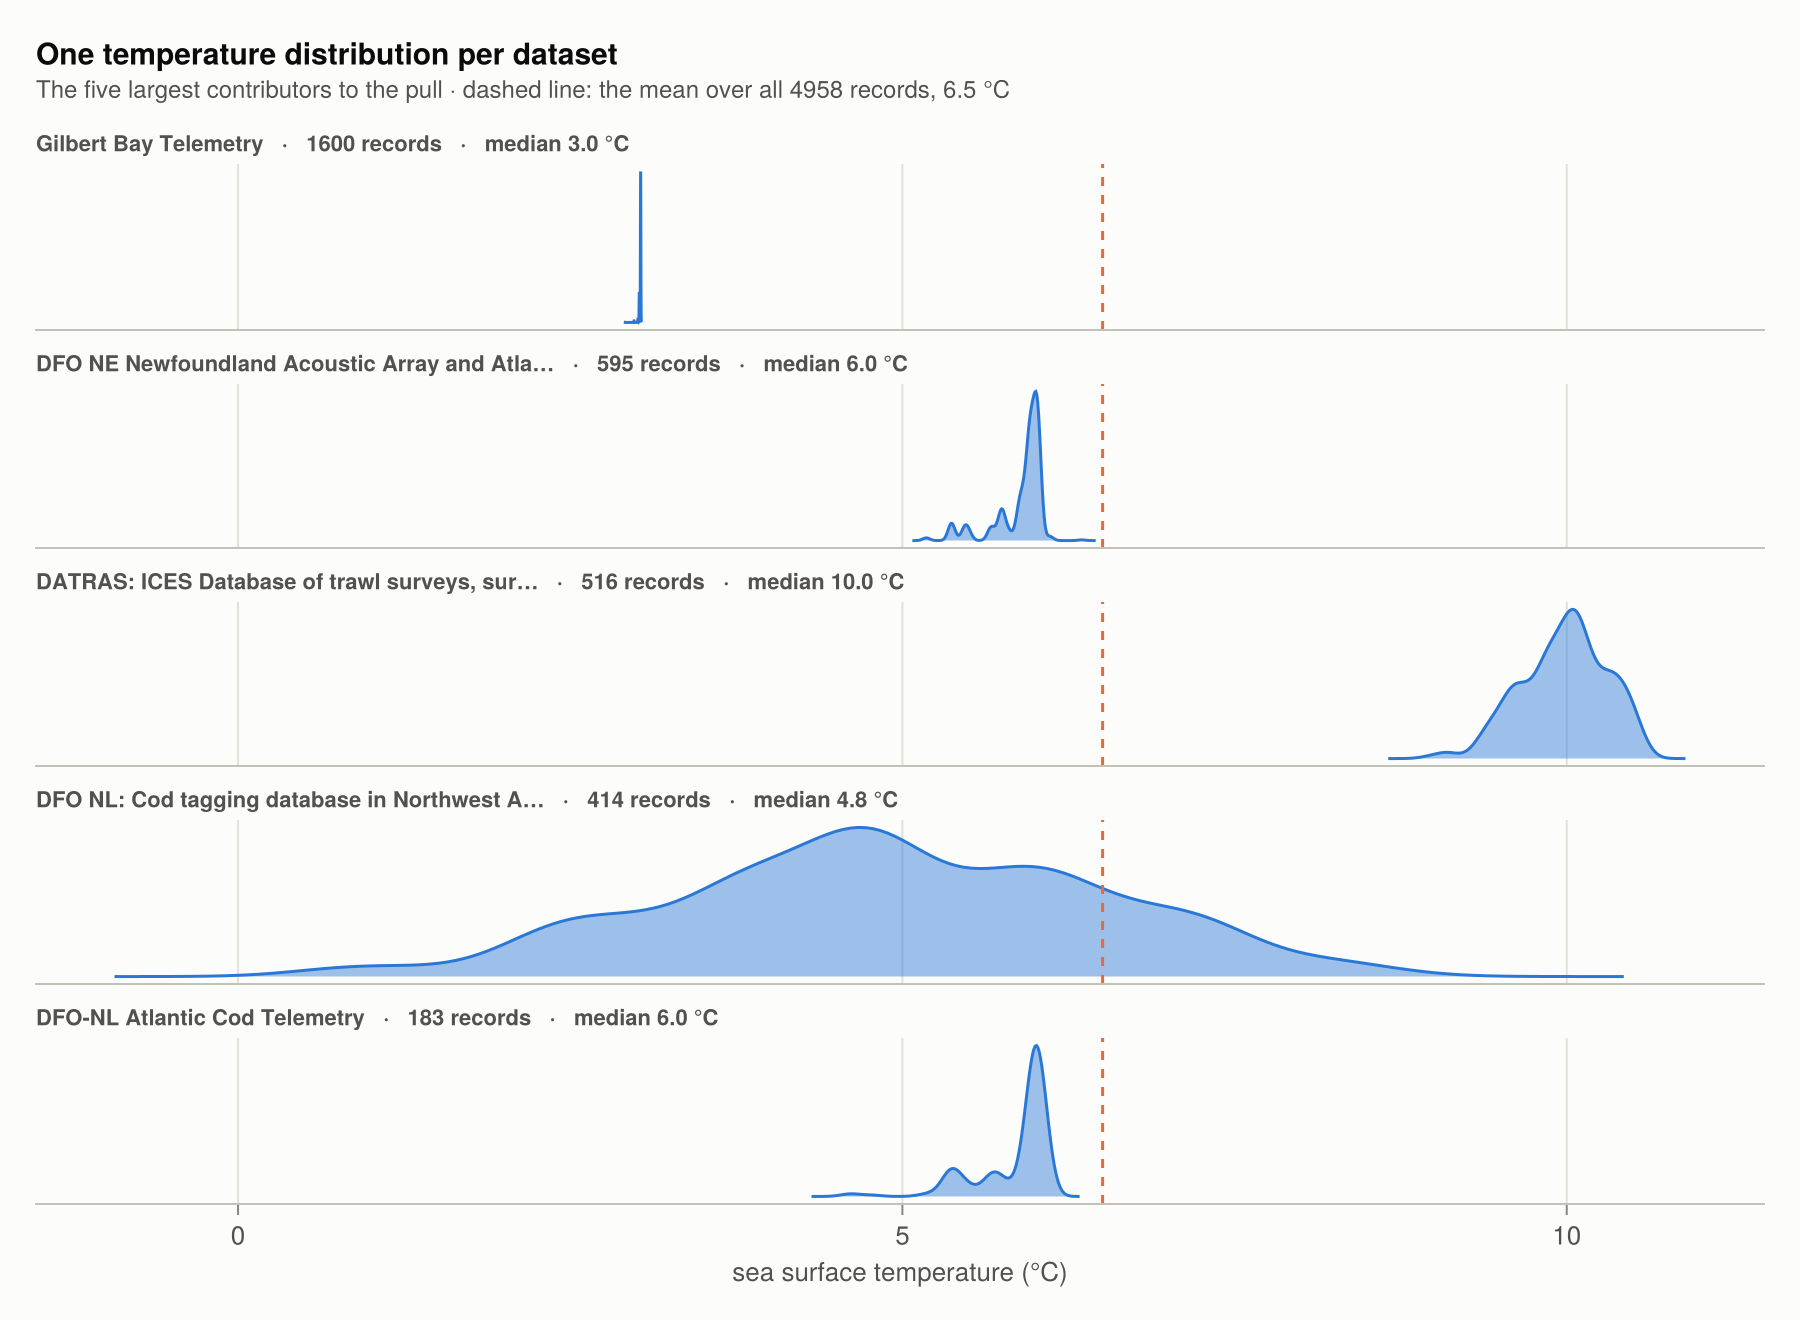

In [8]:
named = dropmissing(df, [:datasetName, :sst])
top   = first(sort(combine(groupby(named, :datasetName), nrow => :records), :records; rev = true), 5)

shorten(s) = length(s) > 46 ? first(s, 43) * "…" : s
overall = mean(values_of(:sst))

fig = Figure(size = (900, 660))
Label(fig[1, 1], "One temperature distribution per dataset";
      color = P.ink, fontsize = 15, font = :bold, halign = :left, tellwidth = false)
Label(fig[2, 1], "The five largest contributors to the pull · dashed line: the mean over all \
      $(length(values_of(:sst))) records, $(round(overall; digits = 1)) °C";
      color = P.ink2, fontsize = 12, halign = :left, tellwidth = false)

axs = Axis[]
for (k, row) in enumerate(eachrow(top))
    x  = named.sst[named.datasetName .== row.datasetName]
    ax = Axis(fig[2 + k, 1];
              title = "$(shorten(row.datasetName))   ·   $(row.records) records   ·   median $(round(median(x); digits = 1)) °C",
              titlesize = 11, titlecolor = P.ink2,
              yticksvisible = false, yticklabelsvisible = false, ygridvisible = false)
    density!(ax, x; color = (P.series1, 0.45), strokecolor = P.series1, strokewidth = 1.5)
    vlines!(ax, [overall]; color = P.series2, linewidth = 1.5, linestyle = :dash)
    k < nrow(top) && hidexdecorations!(ax; grid = false)
    push!(axs, ax)
end
linkxaxes!(axs...)
axs[end].xlabel = "sea surface temperature (°C)"

rowgap!(fig.layout, 1, 2); rowgap!(fig.layout, 2, 14)
for k in 3:(2 + nrow(top) - 1)
    rowgap!(fig.layout, k, 10)
end
fig

Each mode is a programme. An acoustic array in one cold inlet contributes a thousand
detections at a single temperature; a standardized trawl survey contributes a wide, smooth
distribution across a whole sea. Stacked together they make a histogram with holes in it, and
a mean — the dashed line — that falls in a gap where comparatively few records actually are.

The top panel is the extreme case, and worth understanding: a near-vertical spike, because
`sst` is looked up from a grid and a moored receiver never leaves its grid cell. Every
detection it ever logged carries the same temperature. Those are not hundreds of independent
observations of anything.

This is the central caution about occurrence data, stated as a picture. The pull is a census
of *records*, and records are produced by programmes with moorings, budgets and ship time.
Nothing in the table is weighted by area, by effort, or by abundance, so an unweighted mean
over it answers "what temperature do cod records have?" and not "what temperature do cod
live at?".

## Quantiles, drawn

A cumulative distribution is the honest plot for a skewed variable: no bin width to choose,
every quantile readable off the vertical axis, and two groups comparable at a glance.

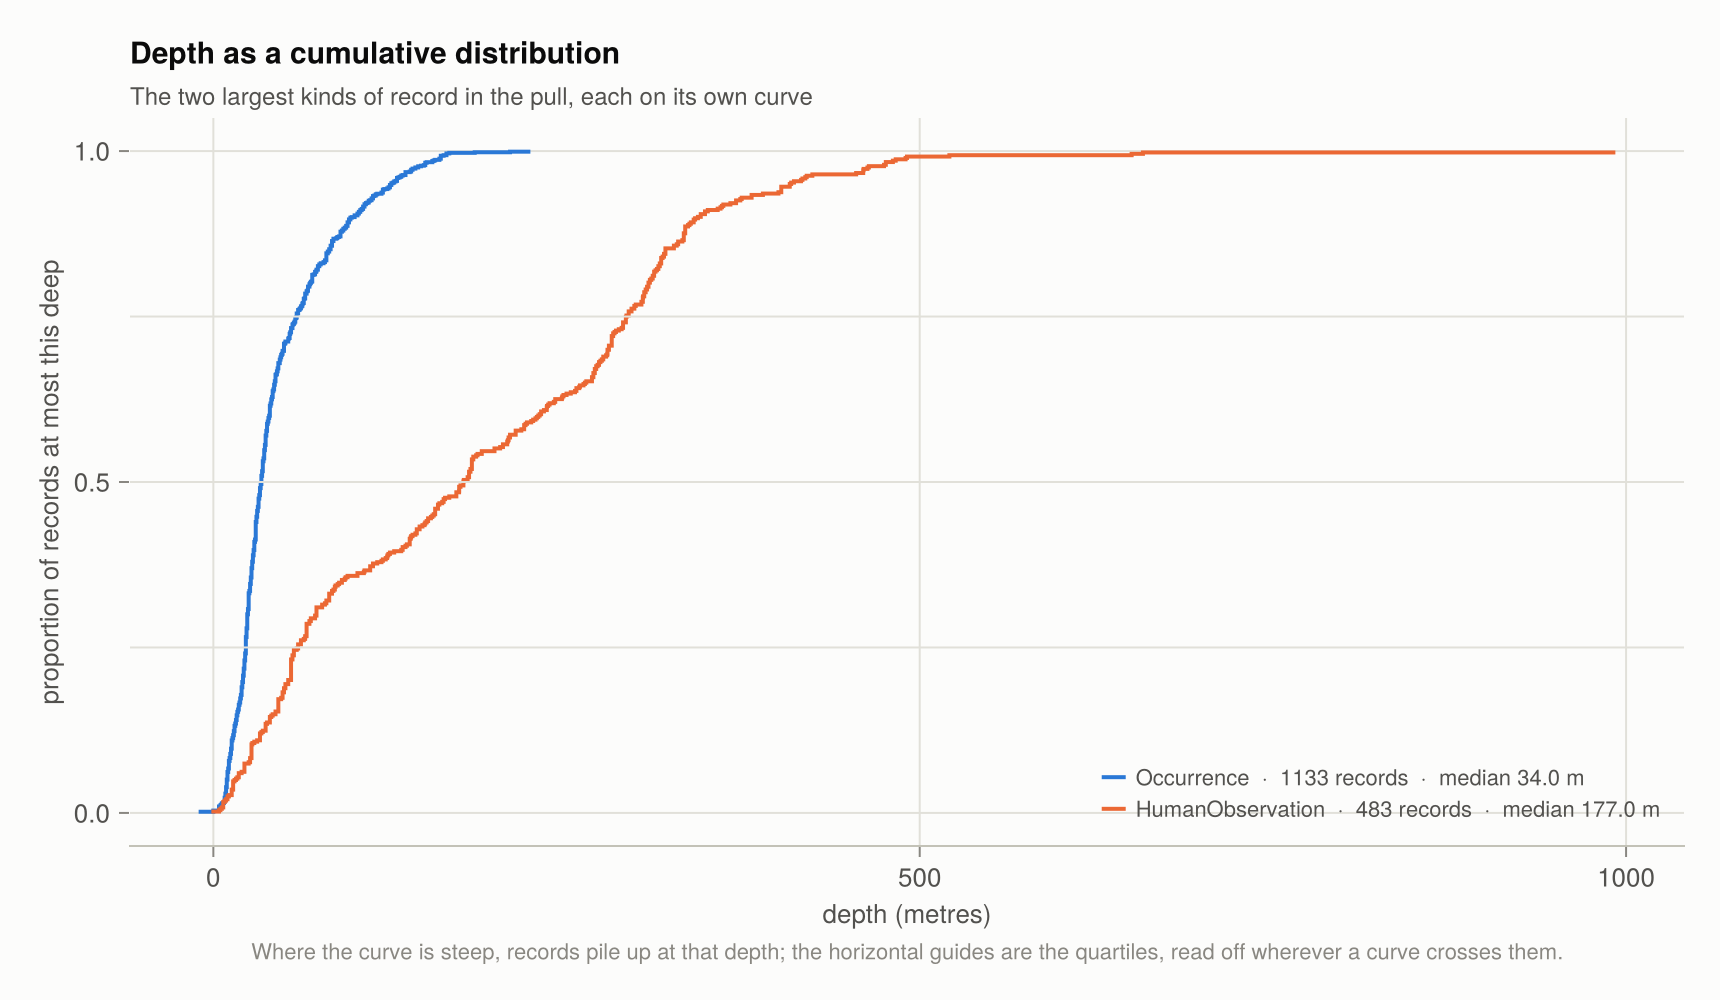

In [9]:
with_depth = dropmissing(df, [:depth, :basisOfRecord])
kinds = first(sort(combine(groupby(with_depth, :basisOfRecord), nrow => :records),
                   :records; rev = true), 2)

fig = Figure(size = (860, 500))
ax  = Axis(fig[1, 1];
           title = "Depth as a cumulative distribution",
           subtitle = "The two largest kinds of record in the pull, each on its own curve",
           xlabel = "depth (metres)", ylabel = "proportion of records at most this deep")

for (k, row) in enumerate(eachrow(kinds))
    x = with_depth.depth[with_depth.basisOfRecord .== row.basisOfRecord]
    ecdfplot!(ax, x; color = k == 1 ? P.series1 : P.series2, linewidth = 2,
              label = "$(row.basisOfRecord)  ·  $(row.records) records  ·  median $(round(median(x); digits = 0)) m")
end
hlines!(ax, [0.25, 0.5, 0.75]; color = P.grid, linewidth = 1)
axislegend(ax; position = :rb)

Label(fig[2, 1],
      "Where the curve is steep, records pile up at that depth; the horizontal guides are the \
      quartiles, read off wherever a curve crosses them.";
      color = P.muted, fontsize = 11, halign = :left, justification = :left,
      tellwidth = false, word_wrap = true)
rowgap!(fig.layout, 1, 6)
fig

The curves separate immediately and never cross: at every depth, one group is shallower than
the other, and their medians differ by a factor of five. That is a stronger statement than a
difference in means, and it survives any amount of skew.

Neither label says much about the fish. `Occurrence` is Darwin Core's unspecified value and
`HumanObservation` covers anything a person wrote down, so what the split really sorts on is
the provider — and the provider is what decided which part of the shelf got sampled and with
what gear.

Which means a model of depth fitted on the pooled column, with no term for how the record was
made, is fitting the mixing proportions of those two groups as much as anything about cod.

## The categorical columns

Counts, with the missing kept in the table rather than dropped quietly.

In [10]:
"Counts of a categorical column, keeping the missing as a category of its own."
function frequencies(df, col; top = 8)
    counts = Dict{String,Int}()
    for x in df[!, col]
        key = ismissing(x) ? "(missing)" : String(x)
        counts[key] = get(counts, key, 0) + 1
    end
    t = DataFrame(value = collect(keys(counts)), records = collect(values(counts)))
    sort!(t, :records; rev = true)
    t.pct = round.(100 .* t.records ./ nrow(df); digits = 1)
    return first(t, top)
end

frequencies(df, :sex)

Row,value,records,pct
,String,Int64,Float64
1,(missing),4347,86.9
2,U,403,8.1
3,unknown,165,3.3
4,9,60,1.2
5,1,7,0.1
6,F,4,0.1
7,male,3,0.1
8,2,3,0.1


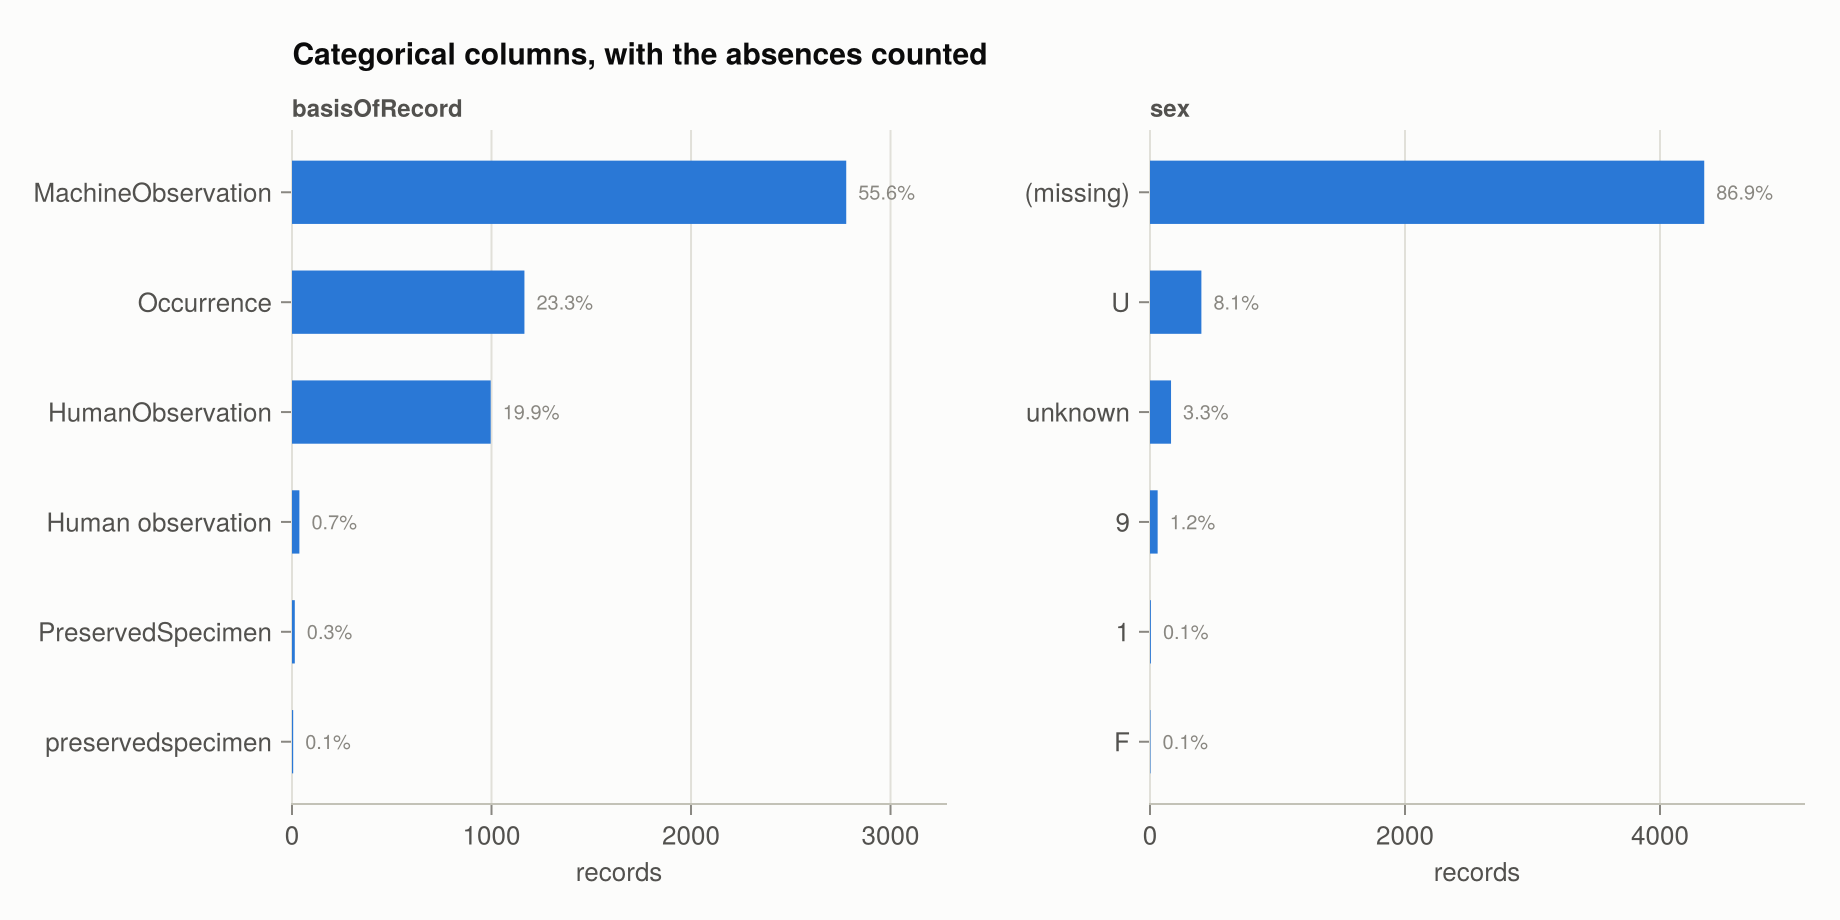

In [11]:
function bars!(ax, t)
    n = nrow(t)
    barplot!(ax, 1:n, t.records; direction = :x, color = P.series1, width = 0.72)
    text!(ax, t.records, 1:n; text = string.(t.pct, "%"), align = (:left, :center),
          offset = (6, 0), color = P.muted, fontsize = 10)
    ax.yticks = (1:n, t.value)
    ax.yreversed = true
    xlims!(ax, 0, maximum(t.records) * 1.18)
    return ax
end

fig = Figure(size = (920, 460))
Label(fig[1, 1:2], "Categorical columns, with the absences counted";
      color = P.ink, fontsize = 15, font = :bold, halign = :left, tellwidth = false)

ax1 = Axis(fig[2, 1]; title = "basisOfRecord", titlesize = 12, titlecolor = P.ink2,
           xlabel = "records", ygridvisible = false)
bars!(ax1, frequencies(df, :basisOfRecord; top = 6))

ax2 = Axis(fig[2, 2]; title = "sex", titlesize = 12, titlecolor = P.ink2,
           xlabel = "records", ygridvisible = false)
bars!(ax2, frequencies(df, :sex; top = 6))

rowgap!(fig.layout, 1, 12); colgap!(fig.layout, 1, 40)
fig

Two things are visible at once.

The vocabularies are not controlled. `sex` arrives as `U`, `unknown`, `9`, `1`, `F` — several
providers' conventions in one column, where `9` and `1` are codes from a coding scheme that
did not travel with the data. Counting the distinct values of that column, or comparing two
of them, requires a decision about what they mean that no software can make for you.

And the majority category is usually absence. Where a field is nearly 90% `(missing)`, the
distribution of the remaining 10% describes whichever handful of datasets record it. What
looks like the sex ratio of five thousand cod is the recording policy of maybe three
programmes.

`basisOfRecord` is the better-behaved column, though it too has `HumanObservation` and
`Human observation` as separate entries — normalize before grouping.

## Counting animals

`individualCount` is the only column here that looks like an abundance, which makes it the
easiest one to misuse.

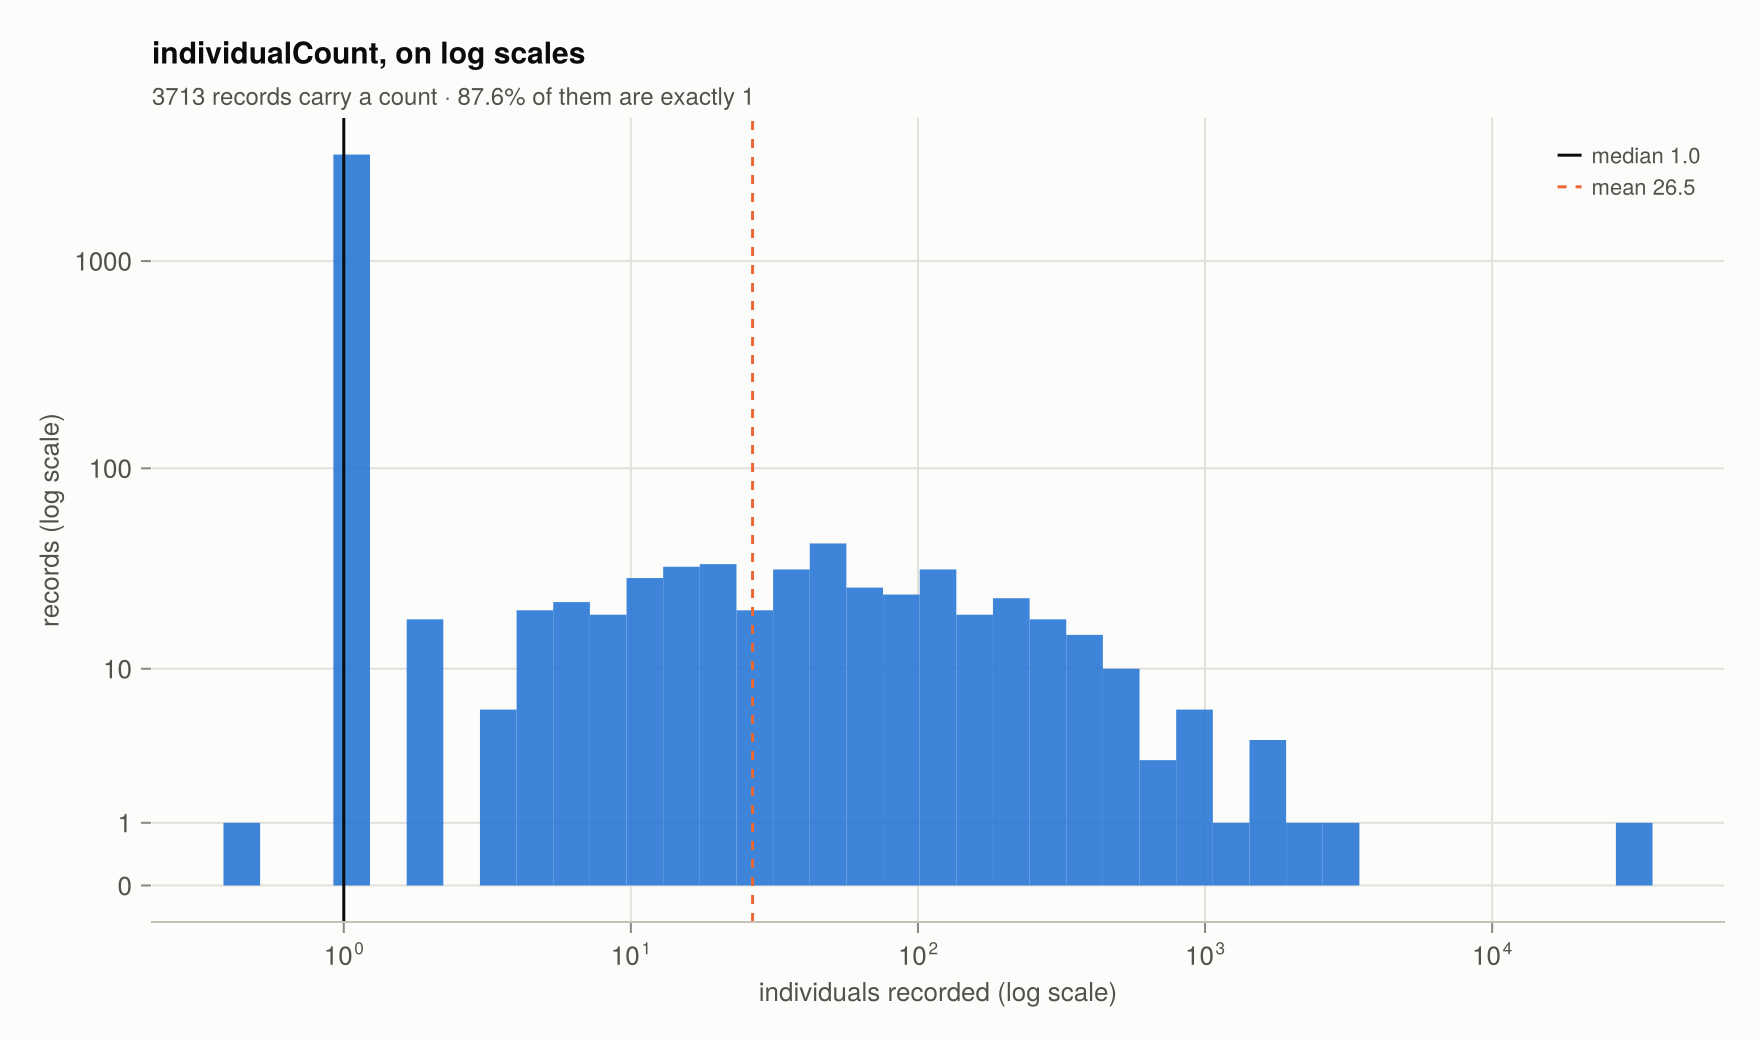

In [12]:
n = values_of(:individualCount)

fig = Figure(size = (880, 520))
ax  = Axis(fig[1, 1];
           title = "individualCount, on log scales",
           subtitle = "$(length(n)) records carry a count · $(round(100 * count(==(1), n) / length(n); digits = 1))% of them are exactly 1",
           xlabel = "individuals recorded (log scale)", ylabel = "records (log scale)",
           xscale = log10, yscale = Makie.pseudolog10, yticks = [0, 1, 10, 100, 1000])
hist!(ax, n; bins = 10 .^ range(log10(minimum(n)), log10(maximum(n)); length = 40),
      color = (P.series1, 0.9), strokewidth = 0)
vlines!(ax, [median(n)]; color = P.ink, linewidth = 1.5, label = "median $(median(n))")
vlines!(ax, [mean(n)]; color = P.series2, linewidth = 1.5, linestyle = :dash,
        label = "mean $(round(mean(n); digits = 1))")
axislegend(ax; position = :rt)
fig

In [13]:
(minimum      = minimum(n),
 fraction_one = round(count(==(1), n) / length(n); digits = 3),
 median       = median(n),
 mean         = round(mean(n); digits = 1),
 q99          = quantile(n, 0.99),
 maximum      = maximum(n),
 fractional   = count(x -> !isinteger(x), n))

(minimum = 0.3809524, fraction_one = 0.876, median = 1.0, mean = 26.5, q99 = 339.7600000000002, maximum = 36201.0, fractional = 1)

Three facts about this column, none of them about how many cod there are.

The overwhelming majority of values are exactly 1. A `1` usually means "a record exists", not
"one fish was counted" — presence written into a count column. Averaging over it therefore
averages a constant over most of the sample.

There are fractional values. A count of 0.38 individuals is a density or a catch-per-effort
figure that was mapped onto `individualCount` on its way into Darwin Core, so the column is
not even in consistent units across datasets.

And the maximum is four or five orders of magnitude above the median, from a trawl haul that
counted a whole catch. Sum this column across a region and the answer is dominated by the few
datasets that report real counts, weighted by how many hauls they published.

## How the columns move together

Spearman's ρ on every pair — rank correlation, so a monotone relationship counts whatever its
shape, and outliers of the kind seen above cannot bend it the way they bend Pearson's.

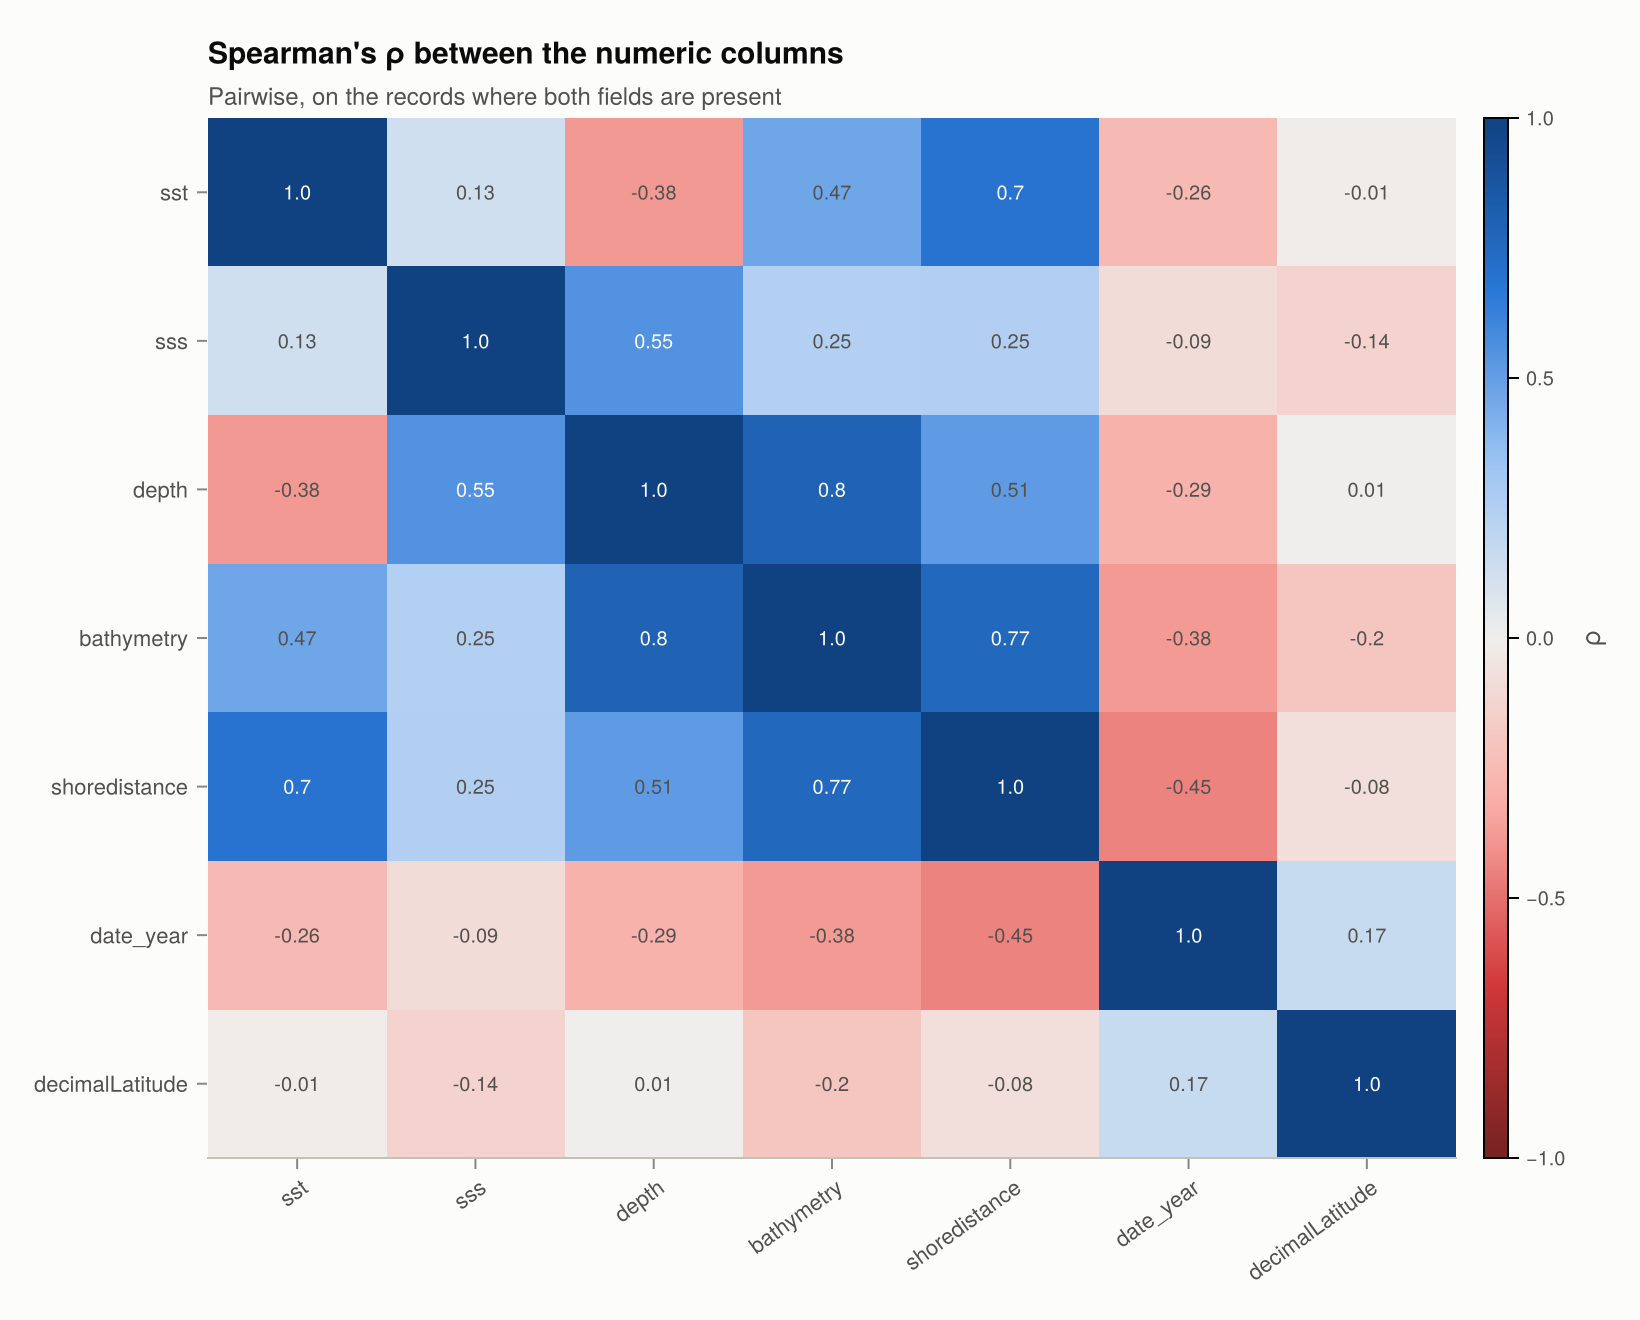

In [14]:
"Spearman's rank correlation over the records where both fields are present."
function spearman(a, b)
    ok = .!ismissing.(a) .& .!ismissing.(b)
    count(ok) < 30 && return NaN
    rank(v) = Float64.(invperm(sortperm(v)))
    return cor(rank(Float64.(collect(a[ok]))), rank(Float64.(collect(b[ok]))))
end

fields = [:sst, :sss, :depth, :bathymetry, :shoredistance, :date_year, :decimalLatitude]
M = [spearman(df[!, i], df[!, j]) for i in fields, j in fields]

fig = Figure(size = (820, 660))
ax  = Axis(fig[1, 1];
           title = "Spearman's ρ between the numeric columns",
           subtitle = "Pairwise, on the records where both fields are present",
           xticks = (1:length(fields), string.(fields)),
           yticks = (1:length(fields), string.(fields)),
           xticklabelrotation = π / 5, yreversed = true,
           xgridvisible = false, ygridvisible = false,
           xticklabelsize = 11, yticklabelsize = 11)

hm = heatmap!(ax, 1:length(fields), 1:length(fields), M;
              colormap = cgrad(P.div), colorrange = (-1, 1), nan_color = P.grid)
for i in eachindex(fields), j in eachindex(fields)
    isnan(M[i, j]) && continue
    text!(ax, i, j; text = string(round(M[i, j]; digits = 2)), align = (:center, :center),
          fontsize = 10, color = abs(M[i, j]) > 0.55 ? P.surface : P.ink2)
end
Colorbar(fig[1, 2], hm; label = "ρ", labelcolor = P.ink2, ticklabelcolor = P.ink2,
         ticklabelsize = 10, width = 12)
colgap!(fig.layout, 1, 14)
fig

The strong entries are geography restating itself. `bathymetry` against `shoredistance` is the
continental shelf: the further from land, the deeper the water. `depth` against `bathymetry`
is the same fact from the provider's side — related but not equivalent, since `depth` is where
the provider says the observation happened and `bathymetry` is how deep the sea floor is at
that coordinate.

The interesting cell is `sst` against `decimalLatitude`, at ρ near zero. The ocean's
temperature gradient should be one of the strongest relationships available in any marine
dataset, and here it has been erased: the pull spans two sides of the Atlantic, and the cold
Labrador coast sits at the same latitudes as a much warmer northwest Europe. Pool them and
latitude predicts nothing.

`sst` against `shoredistance` is the same artefact with the sign flipped into something that
looks meaningful. It says the offshore records are the warm ones, which is true of this
collection of programmes — the inshore arrays are in Newfoundland, the offshore hauls are in
the North and Baltic Seas — and not of the ocean. A correlation matrix over a pull of
occurrence records is, in large part, a portrait of who contributed it.

## Is the pull representative?

Everything above describes five thousand records. `statistics_env` describes the *whole*
query — three million records — without sending any of them, by returning counts per
environmental bin. That makes the comparison cheap, and it is the check worth running before
believing any of the shapes above.

In [15]:
env    = OBISClient.statistics_env(SPECIES)
edges  = [Int(b["sst"]) for b in env["sst"]]
whole  = [Int(b["records"]) for b in env["sst"]]
sample = [count(x -> e <= x < e + 5, values_of(:sst)) for e in edges]

comparison = DataFrame(
    bin        = ["$(e) to $(e + 5)" for e in edges],
    sample     = sample,
    sample_pct = round.(100 .* sample ./ sum(sample); digits = 1),
    whole_pct  = round.(100 .* whole ./ sum(whole); digits = 1),
)

Row,bin,sample,sample_pct,whole_pct
,String,Int64,Float64,Float64
1,-5 to 0,2,0.0,0.1
2,0 to 5,1903,38.4,39.1
3,5 to 10,1888,38.1,37.6
4,10 to 15,1164,23.5,23.1
5,15 to 20,1,0.0,0.0
6,20 to 25,0,0.0,0.0
7,25 to 30,0,0.0,0.0


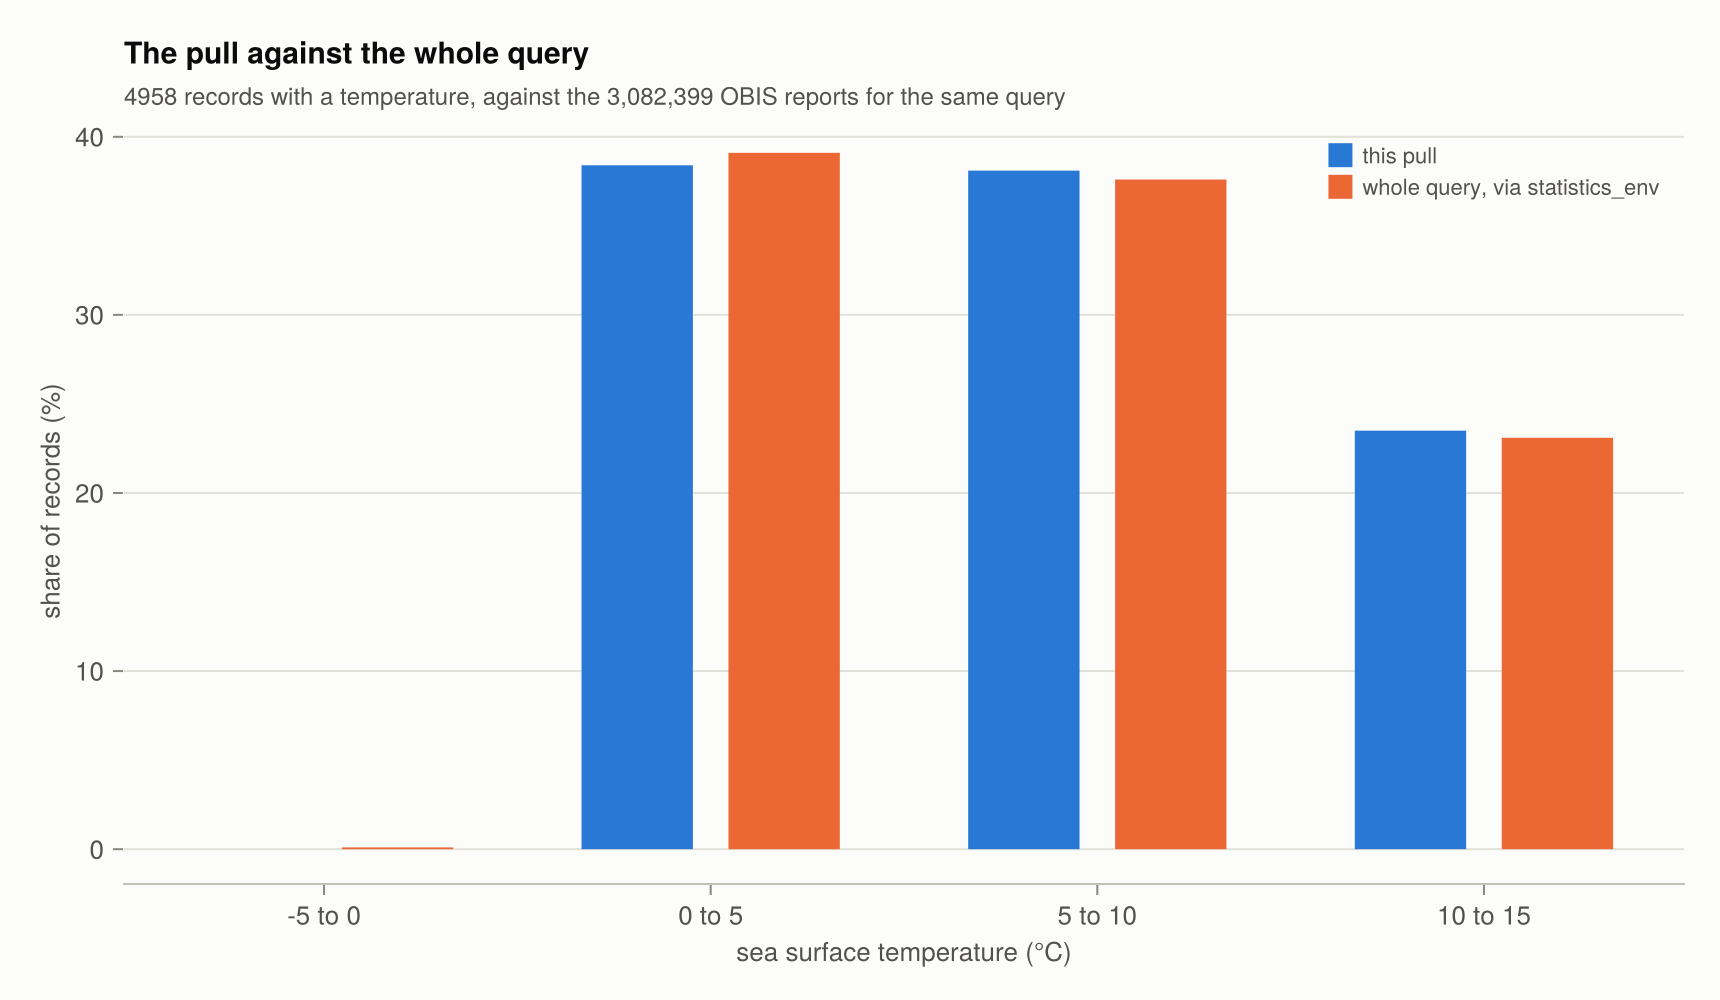

In [16]:
thousands(n) = replace(string(n), r"(?<=[0-9])(?=(?:[0-9]{3})+$)" => ",")

keep = findall(>(0.05), comparison.whole_pct)

fig = Figure(size = (860, 500))
ax  = Axis(fig[1, 1];
           title = "The pull against the whole query",
           subtitle = "$(sum(sample)) records with a temperature, against the $(thousands(sum(whole))) OBIS reports for the same query",
           xlabel = "sea surface temperature (°C)", ylabel = "share of records (%)",
           xticks = (1:length(keep), comparison.bin[keep]), xgridvisible = false)

barplot!(ax, (1:length(keep)) .- 0.19, comparison.sample_pct[keep];
         width = 0.36, color = P.series1, label = "this pull")
barplot!(ax, (1:length(keep)) .+ 0.19, comparison.whole_pct[keep];
         width = 0.36, color = P.series2, label = "whole query, via statistics_env")
axislegend(ax; position = :rt)
fig

The two columns agree to within a percentage point or so. The UUID ordering behaves as
advertised: five thousand records are enough to reproduce the temperature distribution of
three million.

Which is precisely the point to end on. **The sample is representative of the query. The
query is not representative of the ocean.** Pulling more records would have changed nothing
about the multimodality, the 1-heavy counts, or the nine-in-ten missing `sex` — those are properties
of what OBIS has been given, and no sample size fixes them. What fixes them is knowing which
datasets you are looking at, which is why `dataset_id` is worth carrying through an analysis
and why the licence and citation travel on every row.

## The licence did not go away

Descriptive statistics are still use. Rights and citations travel on the result, and in a
multi-dataset pull the most restrictive licence governs the whole.

In [17]:
OBISClient.licenses(recs)

OBISTable: 4 records, 7 columns
  endpoint:  licenses
  accessed:  2026-09-12
  query:     scientificname=Gadus morhua
  licenses:  CC-BY-4.0, CC-BY-NC-4.0, CC0-1.0, unknown
  columns:   license, datasets, records, permits_redistribution, permits_commercial_use, requires_attribution, url

```julia
write("obis-references.bib", OBISClient.citations(recs; format = :bibtex))
```

Cite the datasets you used, with the date you accessed them.

## Where to go next

- [`getting-started.ipynb`](https://colab.research.google.com/github/dantebertuzzi/OBISClient.jl/blob/main/notebooks/getting-started.ipynb) — the first query, the flags, the licences, the other endpoints
- [`obis-missingness.ipynb`](https://colab.research.google.com/github/dantebertuzzi/OBISClient.jl/blob/main/notebooks/obis-missingness.ipynb) — the same records read through what is *absent* from them, with [MissingPatterns.jl](https://github.com/dantebertuzzi/MissingPatterns.jl)
- [Interpreting OBIS data](https://dantebertuzzi.github.io/OBISClient.jl/stable/interpreting/) — the flags, the defaults, and what a record does and does not claim
- [A worked example](https://dantebertuzzi.github.io/OBISClient.jl/stable/worked-example/) — killer whales, retrieved, mapped, grouped and pivoted, with the CairoMakie and GeoMakie scripts behind the figures
- [manual.obis.org](https://manual.obis.org) — OBIS's own manual, including the quality control behind these columns